PROPERTY PRICE PREDICTION

In [2]:
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression 
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\yashi\OneDrive\Desktop\Data_file - data_file.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


Exploratory Data Analysis (EDA) with visualizations and summary statistics

In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(4), int64(5), str(1)
memory usage: 1.7 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

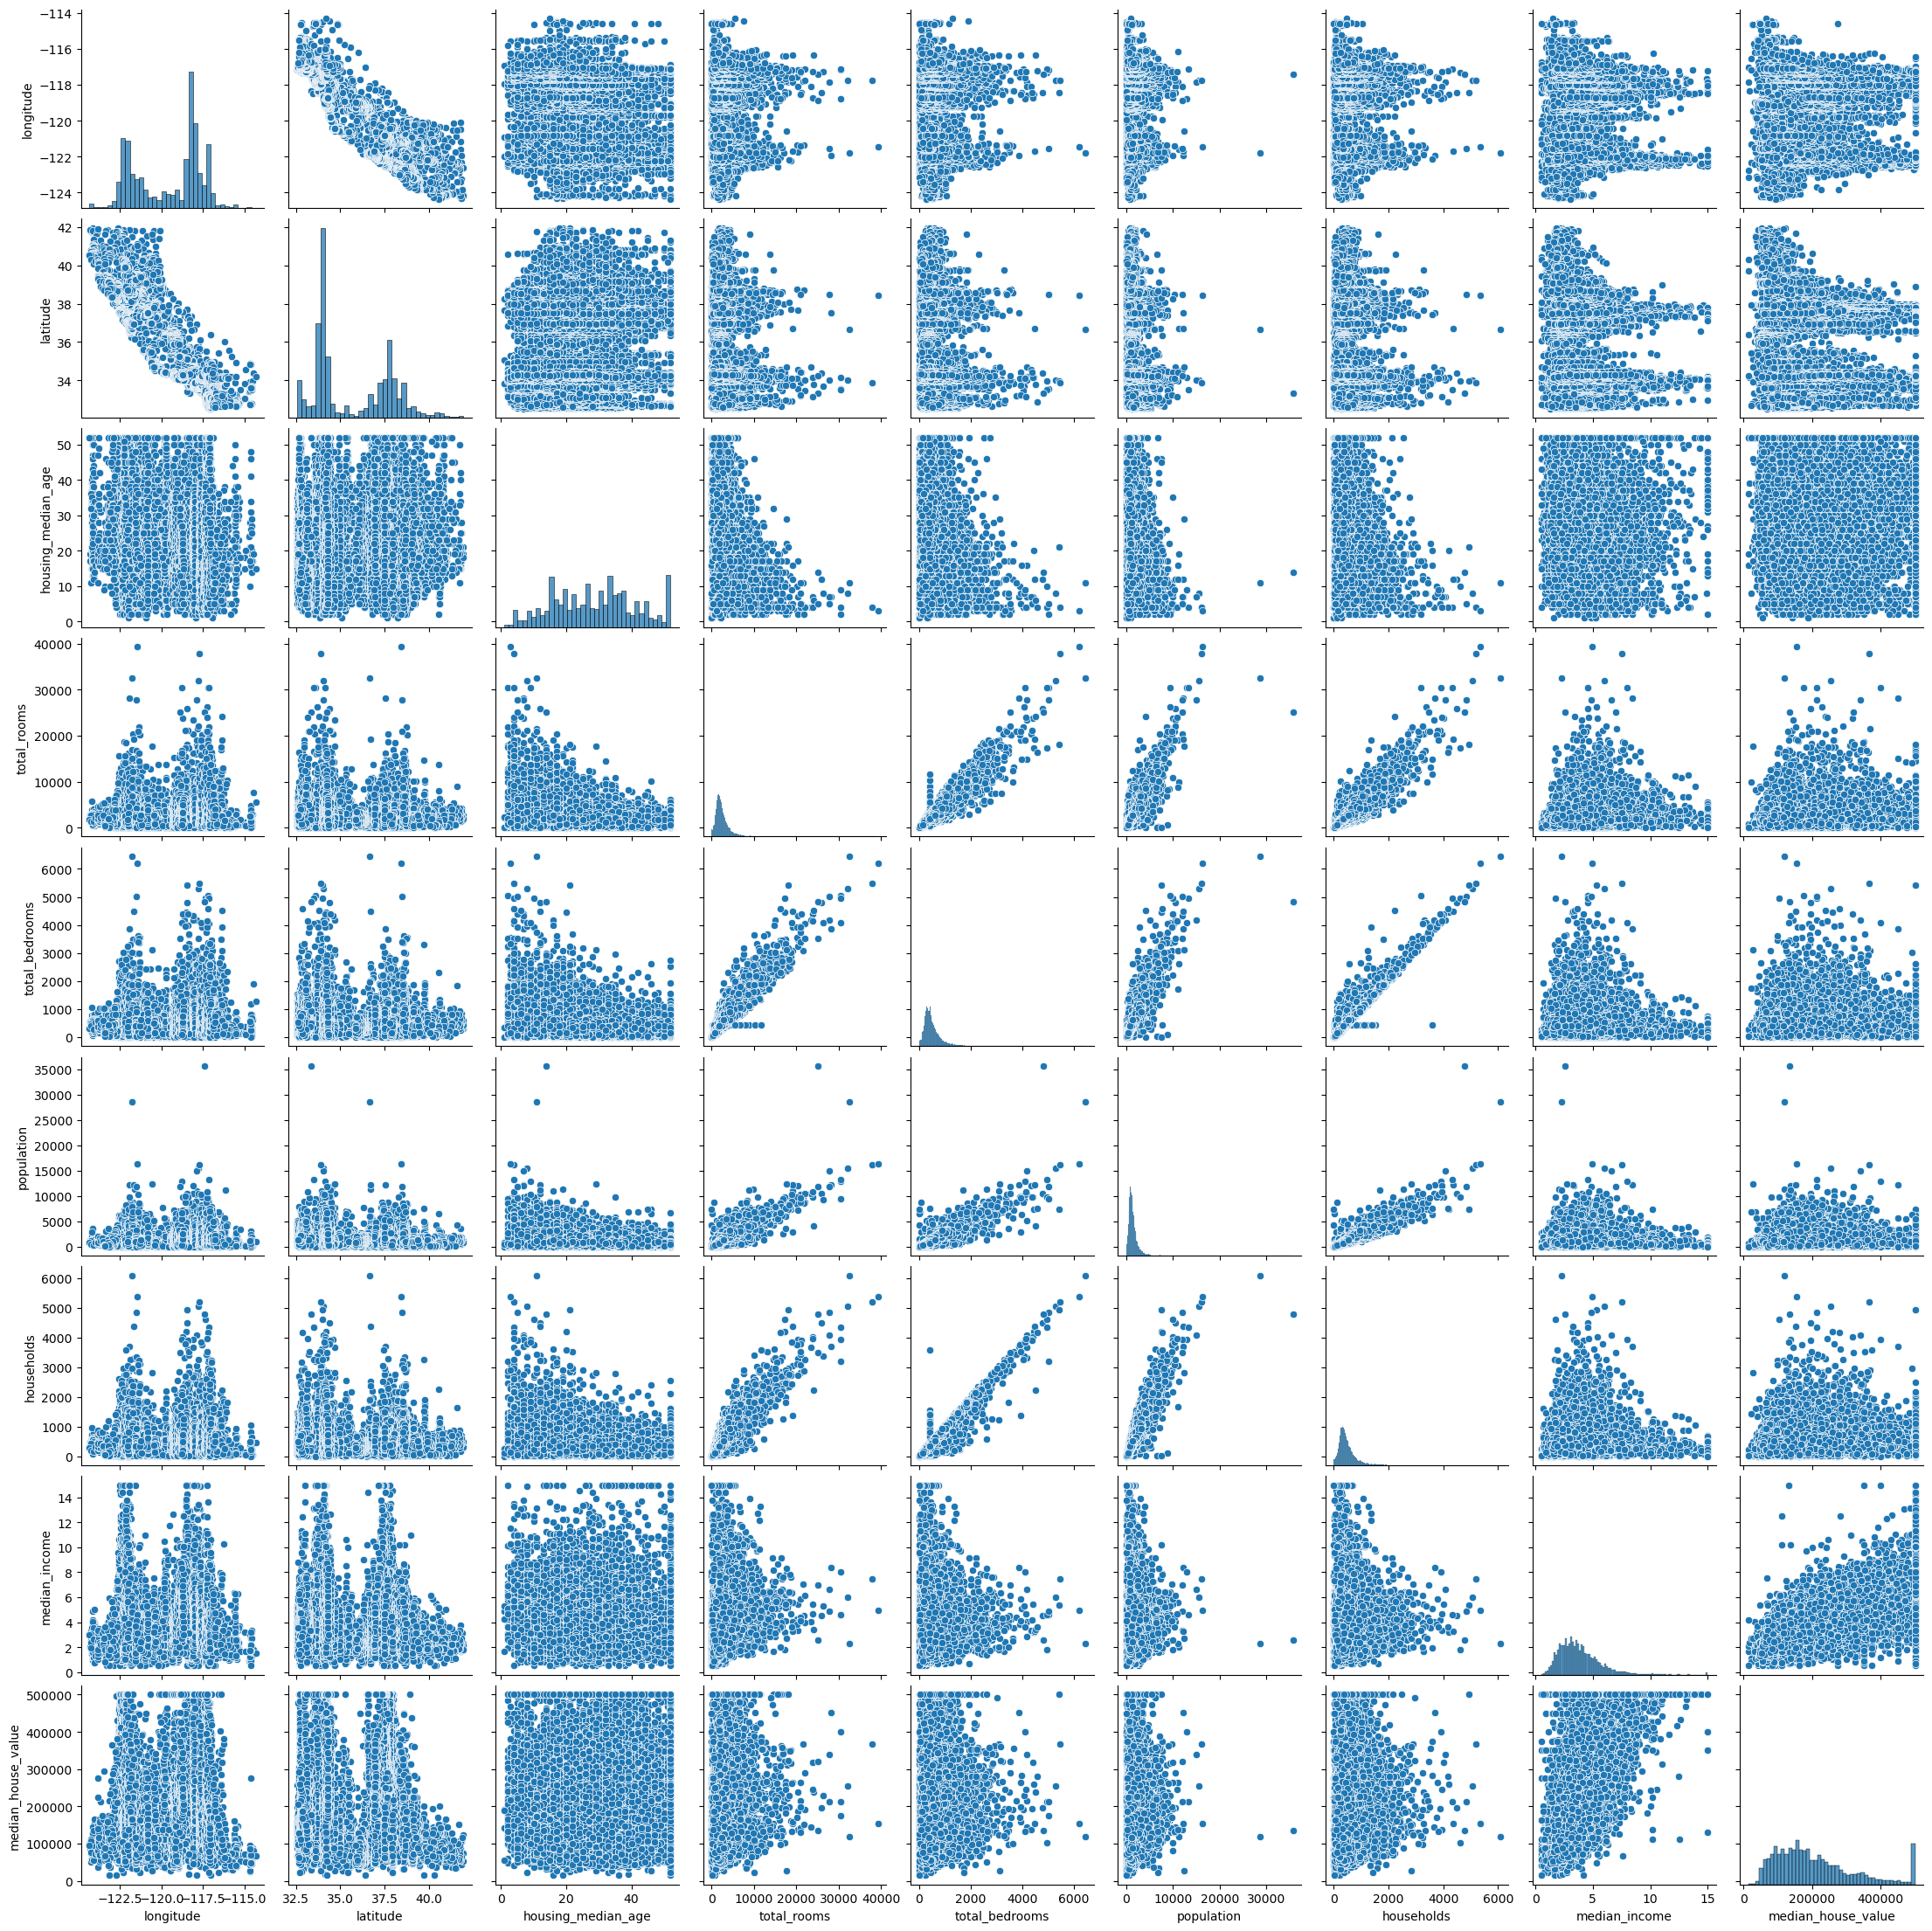

In [7]:
#Pair plot
sns.pairplot(df)
plt.show()

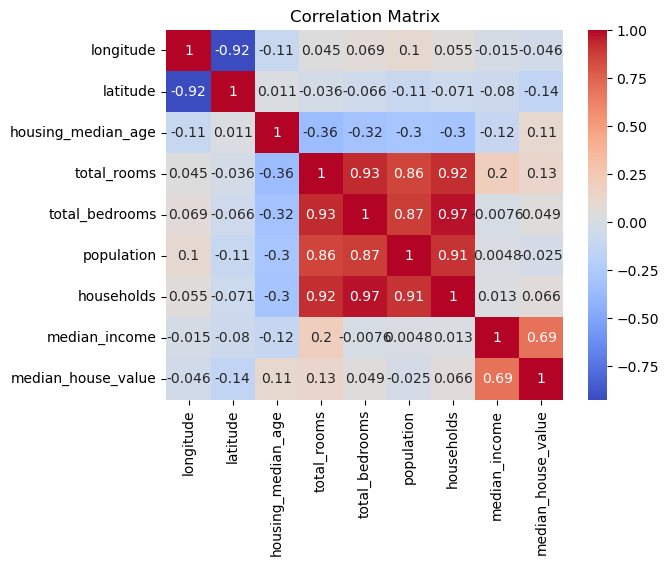

In [8]:
#Correlation matrix

corr_matrix = df[['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value']].corr()

#heat map
sns.heatmap(corr_matrix,annot = True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

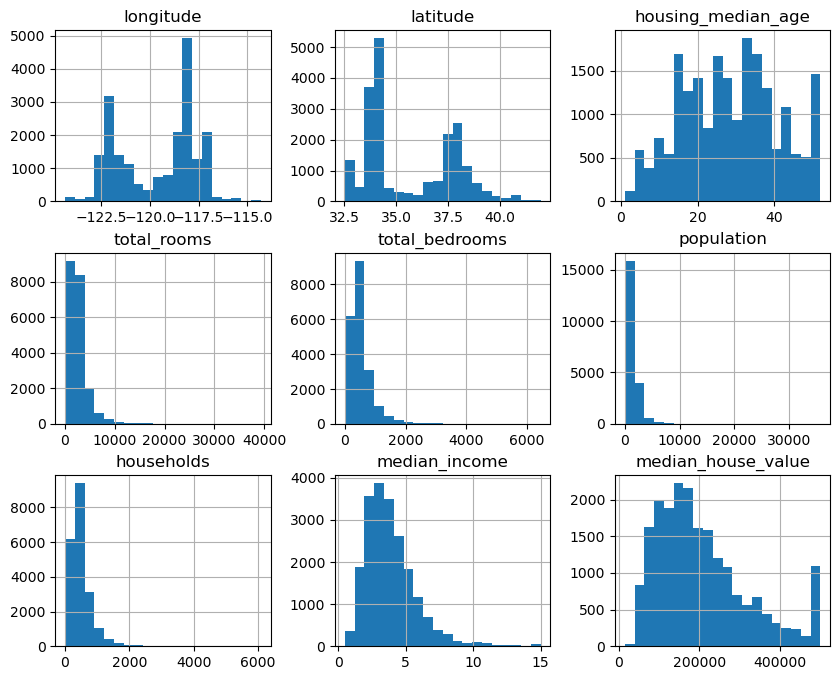

In [9]:
#histogram
df.hist(figsize=(10,8),bins=20)
plt.show()

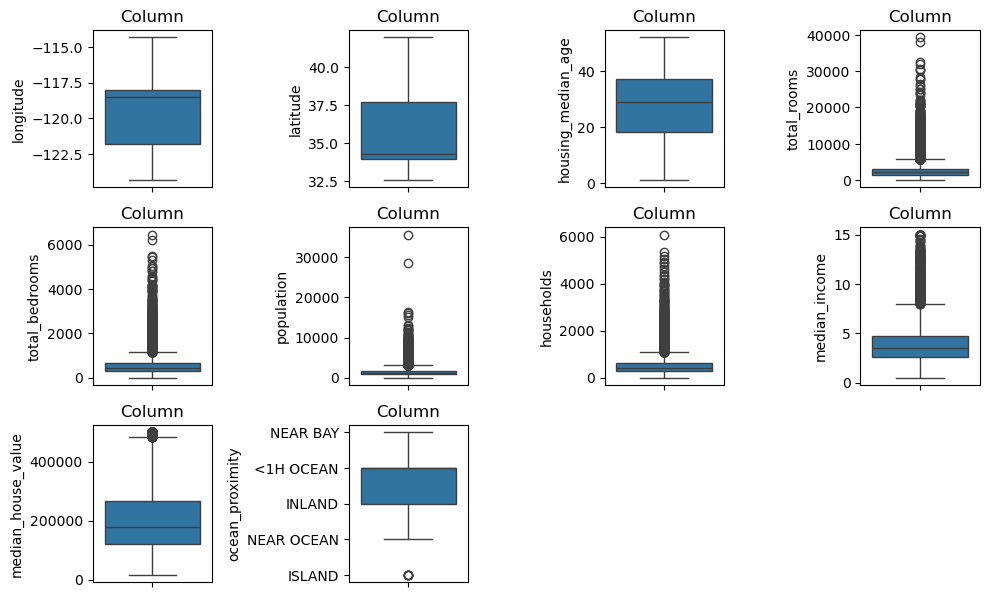

In [10]:
#Box plot 
plt.figure(figsize=(10,8))
for i,column in enumerate (df.columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(df[column])
    plt.title('Column')
plt.tight_layout()
plt.show()

Data Preprocessing (basically Label Encoding)

In [11]:
label = {}
for column in ['ocean_proximity']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label[column] = le

In [12]:
print(df['ocean_proximity'].dtype)

int64


In [13]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,3
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,3
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,3
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,3
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,3


Model Creation

In [14]:
X = df[['median_income']]
y = df[['median_house_value']]

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred = simple_model.predict(X_test)
print(f"Mean squared error: {mean_squared_error(y_test,y_pred)}")
print(f"Root mean squared error: {math.sqrt(mean_squared_error(y_test,y_pred))}")
print(f"R^2 Score: {r2_score(y_test,y_pred)}")

Mean squared error: 6917979868.0485
Root mean squared error: 83174.39430526982
R^2 Score: 0.47293192589970223


In [19]:
y_input = float(input("Enter the median income: "))
y_array = np.array([[y_input]])
y_input_pred = simple_model.predict(y_array)
print(f"The predicted value of the property for {y_input} median income is: {y_input_pred[0][0]:.2f}")

Enter the median income:  8.3253


The predicted value of the property for 8.3253 median income is: 392953.41


MULTIPLE LINEAR REGRESSION

In [17]:
X_multi = df[['longitude', 'latitude', 'total_rooms', 'total_bedrooms', 'median_income', 'ocean_proximity']]
y_multi = df[['median_house_value']]

X_train_multi,X_test_multi,y_train_multi,y_test_multi = train_test_split(X_multi,y_multi, test_size = 0.3, random_state = 42)
multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train_multi)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y_pred_multi = multi_model.predict(X_test_multi)
print(f"Mean squared error of the multiple linear regression model is: {mean_squared_error(y_test_multi,y_pred_multi)}")
print(f"Root mean squared error: {math.sqrt(mean_squared_error(y_test_multi,y_pred_multi))}")
print(f"R^2 Score: {r2_score(y_test_multi,y_pred_multi)}")

Mean squared error of the multiple linear regression model is: 5313609506.038702
Root mean squared error: 72894.50943684786
R^2 Score: 0.5951659324994701


In [23]:
longitude = float(input("Enter the longitude: "))
latitude = float(input("Enter the latitude: "))
total_rooms = int(input("Enter the total number of rooms: "))
total_bedrooms = float(input("Enter the total number of bedrooms: "))
median_income = float(input("Enter the median income: "))
ocean_proximity = int(input("Enter the numerical value for this column: "))
user_data = np.array([[longitude, latitude, total_rooms, total_bedrooms, median_income,ocean_proximity]])
y_input_pred_multi = multi_model.predict(user_data)
print(f"The predicted value of the property for {y_input_multi} median income is: {y_input_pred_multi[0][0]:.2f}")

Enter the longitude:  -122.23	
Enter the latitude:  37.88	
Enter the total number of rooms:  880
Enter the total number of bedrooms:  129.0
Enter the median income:  8.3252
Enter the numerical value for this column:  3


The predicted value of the property for 8.3252 median income is: 407661.82
